# M1 - Régression Lasso et Ensembling

**Objectif** : Construire un modèle robuste sur le dataset Ames Housing pour prédire `SalePrice`.

**Fil conducteur** :
- Nettoyage des valeurs manquantes et des erreurs de saisie
- Feature engineering manuel pour enrichir les données
- Encodage ordinal et target encoding pour les variables catégorielles
- Validation croisée d'un Lasso et comparaison avec Ridge et ElasticNet
- Combinaison (Ensembling) des modèles linéaires et de modèles basés sur les arbres (XGBoost, Random Forest) via optimisation pondérée (Scipy).

**Différence avec le notebook M0** :
- La cible est travaillée en `log1p` pour stabiliser sa distribution
- Optimisation poussée des hyperparamètres des modèles linéaires
- Utilisation d'un ensemble pondéré mathématiquement sur les prédictions Out-Of-Fold (OOF) pour générer la soumission finale.

# 1. Importation des librairies

**Objectif** : Charger toutes les dépendances nécessaires au fonctionnement du notebook.

**Actions** :
- Import des librairies classiques d'analyse (`pandas`, `numpy`, `matplotlib`, `seaborn`).
- Import des modules de Machine Learning (`Scikit-Learn`, `XGBoost`).
- Lancement d'un chronomètre pour mesurer le temps d'exécution global.

In [51]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import TargetEncoder, StandardScaler, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
from scipy.optimize import minimize

notebook_start_time = time.perf_counter()


# 2. Chargement et concaténation

**Objectif** : Importer les données brutes et les préparer pour les traitements globaux.

**Actions** :
- Chargement des fichiers `train.csv` et `test.csv`.
- Suppression d'un outlier extrême identifié sur `GrLivArea`.
- Transformation de la variable cible `SalePrice` au format logarithmique (`log1p`) pour corriger son asymétrie.
- Concaténation des deux datasets dans un tableau unique `all_data` pour faciliter les manipulations futures.

In [52]:
# Chargement des datasets d'entraînement et de test
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Outliers à enlever selon la documentation de De Cock (GrLivArea > 4000)
train_df = train_df[train_df["GrLivArea"] < 4000].reset_index(drop=True)

ntrain = len(train_df)
y_train_log = np.log1p(train_df["SalePrice"].copy())

# --- NOTE PÉDAGOGIQUE ---
# Créer 'all_data' est une astuce typique de Kaggle. Cela permet d'appliquer les transformations 
# basiques (additions, soustractions) sur tout le dataset en une seule fois pour gagner du temps.
# ATTENTION : En production réelle, on ne fait jamais ça car on n'a pas les données futures (test).
# ------------------------
all_data = pd.concat([train_df.drop(columns=["SalePrice"]), test_df], axis=0).reset_index(drop=True)

# Sauvegarde des IDs pour la soumission finale Kaggle, puis suppression
test_ids = test_df['Id'].copy()
all_data = all_data.drop(['Id'], axis=1)

print(f"Shape initiale all_data : {all_data.shape}")


Shape initiale all_data : (2915, 79)


# 3. Recherche des valeurs manquantes

**Objectif** : Identifier l'ampleur et la répartition des valeurs nulles dans le jeu de données combiné.

**Actions** :
- Calcul du nombre total et du pourcentage de valeurs manquantes (`NA`) par colonne.
- Affichage trié pour isoler rapidement les variables les plus problématiques (comme `PoolQC`, `MiscFeature`, etc.).

In [53]:
missing_counts = all_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(f"\nDONNÉES MANQUANTES ({len(missing_counts)} colonnes):")
if len(missing_counts) > 0:
    for col, count in missing_counts.head(100).items():
        pct = 100 * count / len(all_data)
        print(f"   {col:20s} : {count:4d} ({pct:5.1f}%)")
else:
    print("   Aucune")



DONNÉES MANQUANTES (34 colonnes):
   PoolQC               : 2907 ( 99.7%)
   MiscFeature          : 2810 ( 96.4%)
   Alley                : 2717 ( 93.2%)
   Fence                : 2345 ( 80.4%)
   MasVnrType           : 1765 ( 60.5%)
   FireplaceQu          : 1420 ( 48.7%)
   LotFrontage          :  486 ( 16.7%)
   GarageQual           :  159 (  5.5%)
   GarageYrBlt          :  159 (  5.5%)
   GarageCond           :  159 (  5.5%)
   GarageFinish         :  159 (  5.5%)
   GarageType           :  157 (  5.4%)
   BsmtExposure         :   82 (  2.8%)
   BsmtCond             :   82 (  2.8%)
   BsmtQual             :   81 (  2.8%)
   BsmtFinType2         :   80 (  2.7%)
   BsmtFinType1         :   79 (  2.7%)
   MasVnrArea           :   23 (  0.8%)
   MSZoning             :    4 (  0.1%)
   BsmtFullBath         :    2 (  0.1%)
   Functional           :    2 (  0.1%)
   BsmtHalfBath         :    2 (  0.1%)
   Utilities            :    2 (  0.1%)
   BsmtFinSF1           :    1 (  0.0%)
   Ex

# 4. Suppression des erreurs de saisie (Valeurs Nulles)

**Objectif** : Retirer les lignes du jeu d'entraînement contenant des `NA` qui sont de véritables erreurs de saisie (et non des absences d'équipement).

**Actions** :
- Définition d'une liste de colonnes où une valeur manquante est anormale (`error_missing_cols`).
- Suppression des lignes concernées uniquement dans `train_df`.
- Réalignement critique : re-calcul de `y_train_log` et re-concaténation propre de `all_data` en veillant à supprimer la colonne `Id`.

In [54]:
# Suppression des lignes contenant des NA considérés comme des erreurs dans train.csv
# Ajouter UNIQUEMENT les colonnes où un NA est considéré comme une vraie erreur de saisie dans "error_missing_cols" !!!
error_missing_cols = [
    'MSZoning',
    'BsmtFullBath', 
    'Functional',
    'BsmtHalfBath',
    'Utilities',
    'BsmtFinSF1',
    'Exterior2nd',
    'Exterior1st',
    'Electrical',
    'TotalBsmtSF',
    'BsmtUnfSF',
    'BsmtFinSF2',
    'KitchenQual',
    'GarageArea',
    'GarageCars',
    'SaleType'
]

print(f"Colonnes à vérifier pour NA erreurs : {error_missing_cols}")

if len(error_missing_cols) > 0:
    valid_error_cols = [c for c in error_missing_cols if c in train_df.columns]
    dropped_error_cols = [c for c in error_missing_cols if c not in train_df.columns]

    if len(dropped_error_cols) > 0:
        print(f"Colonnes ignorées (absentes de train.csv): {dropped_error_cols}")

    n_before_drop = len(train_df)
    train_df = train_df.dropna(subset=valid_error_cols).reset_index(drop=True)
    n_removed = n_before_drop - len(train_df)
    
    ntrain = len(train_df)
    y_train_log = np.log1p(train_df["SalePrice"].copy())

# Créer 'all_data' est une astuce typique de Kaggle. Cela permet d'appliquer les transformations 
# basiques (additions, soustractions) sur tout le dataset en une seule fois pour gagner du temps.
# ATTENTION : En production réelle, on ne fait jamais ça car on ne dispose pas des données futures (test).
# ------------------------
    all_data = pd.concat([train_df.drop(columns=["SalePrice"]), test_df], axis=0).reset_index(drop=True)
    all_data = all_data.drop(['Id'], axis=1)
    
    print(f"Lignes supprimées sur train_df (NA erreurs): {n_removed}")
    print(f"Nouvelle shape all_data : {all_data.shape} (ntrain={ntrain})")
else:
    print("Aucune suppression de lignes: error_missing_cols est vide.")


Colonnes à vérifier pour NA erreurs : ['MSZoning', 'BsmtFullBath', 'Functional', 'BsmtHalfBath', 'Utilities', 'BsmtFinSF1', 'Exterior2nd', 'Exterior1st', 'Electrical', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFinSF2', 'KitchenQual', 'GarageArea', 'GarageCars', 'SaleType']
Lignes supprimées sur train_df (NA erreurs): 1
Nouvelle shape all_data : (2914, 79) (ntrain=1455)


# 5. Nettoyage global et Feature Engineering

**Objectif** : Nettoyer les données et créer de nouvelles variables prédictives (Features) pertinentes.

**Actions** :
- Remplacement des `NA` signifiant "Absence" par la catégorie 'None'.
- Remplacement des `NA` numériques par 0 là où c'est logique (ex: surfaces de garage).
- Imputation intelligente de la façade (`LotFrontage`) par la médiane du quartier.
- Création de nouvelles variables : surface totale (`TotalSF`), nombre de salles de bains (`TotalBath`), âge de la construction (`AgeBuilt`), etc.
- Suppression des colonnes redondantes pour limiter la multicolinéarité.
- Séparation finale des données propres en `X_train_clean` et `X_test_clean`.

In [55]:
def apply_base_preprocessing(data):
    """Applique le nettoyage de base et le Feature Engineering sur l'ensemble complet (Train + Test)"""
    df = data.copy()

    # A. NA signifiant "Absence de l'équipement" -> Catégorie 'None'
    cols_none = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
                 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType']
    for col in cols_none:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    # B. NA signifiant 0 pour les variables numériques
    cols_zero = ['GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 
                 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
    for col in cols_zero:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # C. Imputation par la médiane des maisons situées dans le même quartier pour la façade (LotFrontage)
    if 'LotFrontage' in df.columns:
        df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    # En calculant la médiane sur 'all_data', l'imputation du Train est influencée par le Test.
    # C'est un léger Data Leakage, toléré sur Kaggle, mais considéré comme une erreur en production.
    # ----------------------------------------------
    

    # D. Conversion des variables numériques qui sont en réalité catégorielles (MSSubClass, YrSold, MoSold)
    df['MSSubClass'] = df['MSSubClass'].astype(str)
    df['YrSold'] = df['YrSold'].astype(str)
    df['MoSold'] = df['MoSold'].astype(str)

    # E. Feature Engineering
    # Surface totale habitable (RDC + 1er + 2eme + sous-sol)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # F. Nombre total de salles de bain (les demi-salles comptent pour 0.5)
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
    
    # G. Flag binaire indiquant si la maison a été rénovée
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)
    
    # H. Calcul des âges par rapport à l'année de vente
    df['AgeBuilt'] = df['YrSold'].astype(int) - df['YearBuilt']
    df['AgeRemodAdd'] = df['YrSold'].astype(int) - df['YearRemodAdd']
    
    # I. Age du garage (si pas de garage, on prend l'âge de construction de la maison)
    df['AgeGarage'] = df['YrSold'].astype(int) - df['GarageYrBlt']
    df.loc[df['GarageYrBlt'] == 0, 'AgeGarage'] = df.loc[df['GarageYrBlt'] == 0, 'AgeBuilt']
    
    # J. Surface de porch total
    df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']

    # K. Interactions qualitatives utiles pour les modèles linéaires
    df['QualSF'] = df['OverallQual'] * df['TotalSF']

    # L. Traitement de la Multicolinéarité pour les modèles linéaires régularisés
    # On retire les colonnes redondantes pour éviter l'overfitting et améliorer la stabilité des coefficients
    cols_to_drop = ['TotRmsAbvGrd', 'GarageYrBlt']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

# Application du nettoyage
all_data_clean = apply_base_preprocessing(all_data)

# Séparation Train / Test
X_train_clean = all_data_clean.iloc[:ntrain].copy()
X_test_clean = all_data_clean.iloc[ntrain:].copy()

print(f"Shape X_train_clean : {X_train_clean.shape}")
print(f"Shape X_test_clean  : {X_test_clean.shape}")


Shape X_train_clean : (1455, 85)
Shape X_test_clean  : (1459, 85)


# 6. Encodage avancé des variables catégorielles

**Objectif** : Transformer les variables de texte en valeurs numériques exploitables par les algorithmes mathématiques.

**Actions** :
- Création d'une classe personnalisée `AdvancedCategoricalEngineer` compatible avec Scikit-Learn.
- Encodage Ordinal : transformation des variables de qualité (ex: `Ex`, `Gd`, `TA`, `Fa`, `Po`) en échelle numérique allant de 5 à 1.
- Target Encoding : encodage des variables nominales complexes en remplaçant chaque modalité par la valeur moyenne de la cible (`SalePrice`), de manière lissée et sécurisée.

In [56]:
class AdvancedCategoricalEngineer(BaseEstimator, TransformerMixin):
    """Transformateur Scikit-Learn pour encodage ordinal et Target Encoding (sklearn)."""
    def __init__(self, smoothing=10.0):
        self.smoothing = smoothing
        self.qual_mapping = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
        self.ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                             'HeatingQC', 'KitchenQual', 'FireplaceQu',
                             'GarageQual', 'GarageCond', 'PoolQC']
        self.te = None
        self.nominal_cols = None

    def fit(self, X, y):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        self.nominal_cols = X_copy.select_dtypes(include=['object', 'string']).columns.tolist()

        for col in self.nominal_cols:
            X_copy[col] = X_copy[col].astype(str).fillna('Missing')

        self.te = TargetEncoder(
            categories='auto',
            target_type='continuous',
            smooth=self.smoothing,
            cv=5,
            shuffle=True,
            random_state=42
        )
        self.te.fit(X_copy[self.nominal_cols], y)
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in self.ordinal_cols:
            if col in X_copy.columns:
                X_copy[col] = X_copy[col].map(self.qual_mapping).fillna(0)

        if self.nominal_cols:
            for col in self.nominal_cols:
                if col in X_copy.columns:
                    X_copy[col] = X_copy[col].astype(str).fillna('Missing')
            X_copy[self.nominal_cols] = self.te.transform(X_copy[self.nominal_cols])

        return X_copy


# 7. Validation Croisée : Régression Lasso Baseline

**Objectif** : Obtenir une première estimation robuste des performances d'un modèle Lasso simple.

**Actions** :
- Définition d'un schéma de validation croisée (`KFold` à 5 dossiers).
- Construction d'un `Pipeline` intégrant l'encodage catégoriel, la standardisation et l'algorithme `Lasso`.
- Entraînement et évaluation sur chaque dossier (fold) pour calculer le score RMSE moyen sans overfitting.

In [57]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scores = []

print("\nDébut Validation Croisée Lasso (5-Fold)...")
pipeline_m1_lasso = Pipeline([
    ('encoder', AdvancedCategoricalEngineer(smoothing=10.0)),
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.0005, max_iter=20000))
])

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_clean)):
    X_tr, y_tr = X_train_clean.iloc[train_idx], y_train_log.iloc[train_idx]
    X_val, y_val = X_train_clean.iloc[val_idx], y_train_log.iloc[val_idx]

    pipeline_m1_lasso.fit(X_tr, y_tr)
    preds = pipeline_m1_lasso.predict(X_val)

    fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(fold_rmse)
    print(f"Fold {fold + 1} | RMSE: {fold_rmse:.5f}")

print(f"\nRMSE Moyen (CV) : {np.mean(rmse_scores):.5f} (+/- {np.std(rmse_scores):.5f})")



Début Validation Croisée Lasso (5-Fold)...
Fold 1 | RMSE: 0.11984
Fold 2 | RMSE: 0.12275
Fold 3 | RMSE: 0.12338
Fold 4 | RMSE: 0.12598
Fold 5 | RMSE: 0.09636

RMSE Moyen (CV) : 0.11766 (+/- 0.01083)


# 8. Analyse de la Multicolinéarité

**Objectif** : Identifier les variables numériques trop fortement corrélées entre elles pour prévenir l'instabilité du modèle linéaire.

**Actions** :
- Calcul de la matrice de corrélation de Pearson sur le jeu d'entraînement nettoyé.
- Affichage des paires de variables présentant une très forte corrélation (supérieure à 0.85).
- Génération d'une carte de chaleur (Heatmap) pour visualiser l'ensemble des dépendances linéaires.


ANALYSE MULTICOLINÉARITÉ

Corrélations fortes (|r| > 0.85):
------------------------------------------------------------
   OverallQual          <-> QualSF               : 0.873
   YearBuilt            <-> AgeBuilt             : -0.999
   YearRemodAdd         <-> AgeRemodAdd          : -0.998
   GrLivArea            <-> TotalSF              : 0.861
   GarageCars           <-> GarageArea           : 0.887
   TotalSF              <-> QualSF               : 0.927

Heatmap de corrélation (variables numériques):


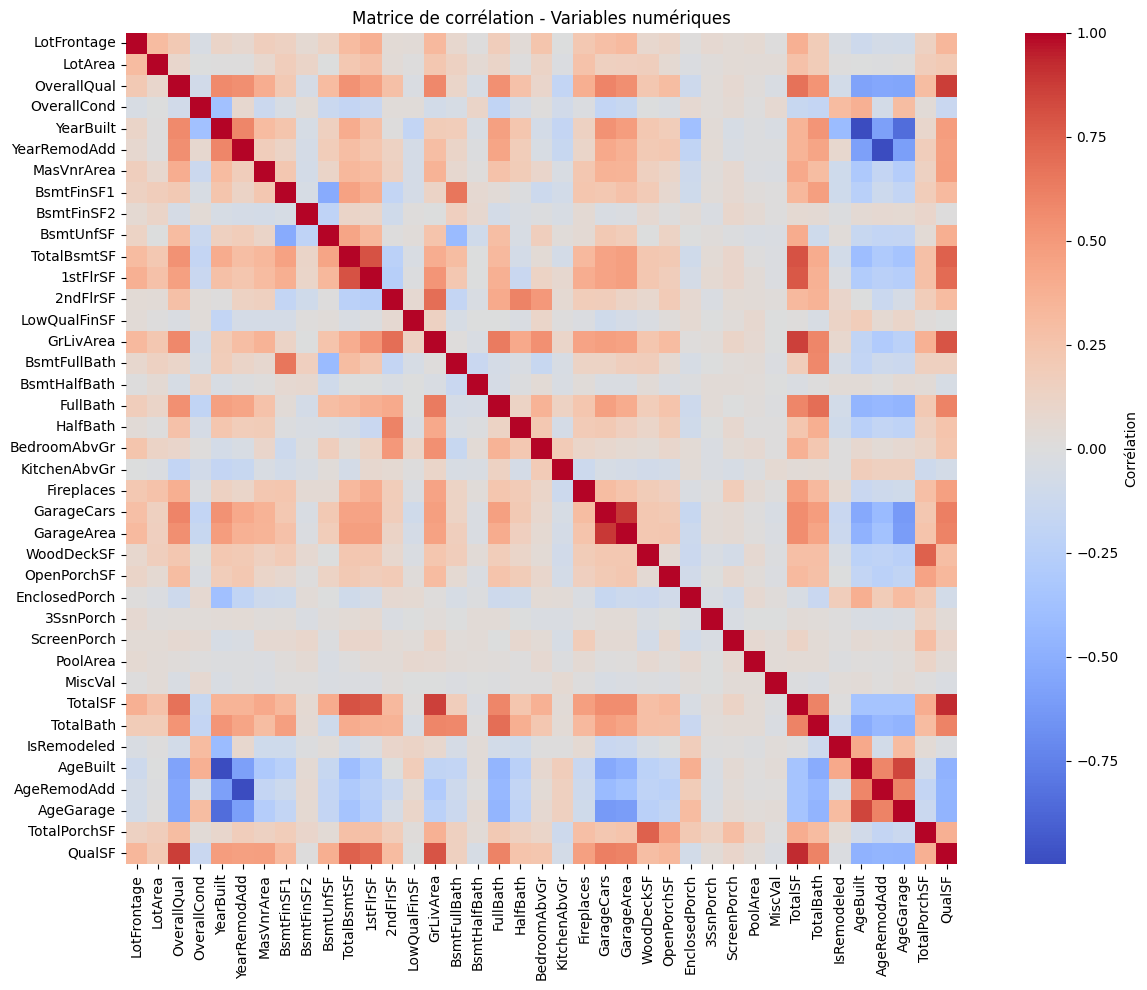

In [58]:
print("\n" + "="*70)
print("ANALYSE MULTICOLINÉARITÉ")
print("="*70)

numeric_features = X_train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_clean.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
correlation_matrix = X_train_clean[numeric_features].corr()

print("\nCorrélations fortes (|r| > 0.85):")
print("-" * 60)

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.85:
            col_i = correlation_matrix.columns[i]
            col_j = correlation_matrix.columns[j]
            corr_value = correlation_matrix.iloc[i, j]
            high_corr_pairs.append((col_i, col_j, corr_value))
            print(f"   {col_i:20s} <-> {col_j:20s} : {corr_value:.3f}")

if len(high_corr_pairs) == 0:
    print("   Aucune corrélation forte détectée")

# Heatmap
print("\nHeatmap de corrélation (variables numériques):")
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False, square=True, cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation - Variables numériques')
plt.tight_layout()
plt.show()


# 9. Pipelines optimisés pour modèles linéaires

**Objectif** : Trouver les meilleurs hyperparamètres pour nos différents modèles linéaires avant de les combiner.

**Actions** :
- Construction d'un `ColumnTransformer` scindant le traitement des variables numériques (avec `QuantileTransformer`) et catégorielles (avec `TargetEncoder`).
- Recherche automatique des meilleures pénalités (`alpha`) pour `LassoCV`, `RidgeCV` et `ElasticNetCV`.
- Affichage des meilleurs hyperparamètres trouvés pour chaque algorithme.

In [59]:
print("\n" + "="*70)
print("PIPELINES OPTIMISÉS POUR LES MODÈLES LINÉAIRES (Lasso, Ridge, ElasticNet)")
print("="*70)

# Contrairement au 'all_data' ci-dessus, l'idée est de placer le TargetEncoder et le QuantileTransformer dans un Pipeline Scikit-Learn. 
# Ils seront 'fit' uniquement sur les données d'entraînement dans la boucle de Validation Croisée. Cela évite le Data Leakage qui fausserait complètement le modèle
numeric_transformer_optimized = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', QuantileTransformer(output_distribution='normal', random_state=42))
])

categorical_transformer_optimized = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(categories='auto', target_type='continuous', smooth='auto', cv=5))
])

numeric_features_valid = [c for c in numeric_features if c in X_train_clean.columns]
categorical_features_valid = [c for c in categorical_features if c in X_train_clean.columns]

preprocessor_optimized = ColumnTransformer(transformers=[
    ('num', numeric_transformer_optimized, numeric_features_valid),
    ('cat', categorical_transformer_optimized, categorical_features_valid)
])

# 1. LassoCV
lasso_optimized = LassoCV(alphas=np.logspace(-6, 1, 1000), cv=5, random_state=42, max_iter=20000, tol=1e-4)
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor_optimized),
    ('model', lasso_optimized)
])

# 2. RidgeCV
ridge_optimized = RidgeCV(alphas=np.logspace(-3, 3, 200), cv=5)
pipeline_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor_optimized),
    ('model', ridge_optimized)
])

# 3. ElasticNetCV
enet_optimized = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], alphas=np.logspace(-6, 1, 200), cv=5, random_state=42, max_iter=20000)
pipeline_enet = Pipeline(steps=[
    ('preprocessor', preprocessor_optimized),
    ('model', enet_optimized)
])

print("\nEntraînement des modèles linéaires optimisés...")
y_train_for_fit = y_train_log.iloc[: X_train_clean.shape[0] ].reset_index(drop=True)

pipeline_lasso.fit(X_train_clean, y_train_for_fit)
pipeline_ridge.fit(X_train_clean, y_train_for_fit)
pipeline_enet.fit(X_train_clean, y_train_for_fit)

print(f"   Lasso alpha optimal       : {pipeline_lasso.named_steps['model'].alpha_:.6f}")
print(f"   Ridge alpha optimal       : {pipeline_ridge.named_steps['model'].alpha_:.6f}")
print(f"   ElasticNet alpha optimal  : {pipeline_enet.named_steps['model'].alpha_:.6f}")
print(f"   ElasticNet l1_ratio opt   : {pipeline_enet.named_steps['model'].l1_ratio_:.2f}")



PIPELINES OPTIMISÉS POUR LES MODÈLES LINÉAIRES (Lasso, Ridge, ElasticNet)

Entraînement des modèles linéaires optimisés...
   Lasso alpha optimal       : 0.000302
   Ridge alpha optimal       : 2.736440
   ElasticNet alpha optimal  : 0.000341
   ElasticNet l1_ratio opt   : 1.00


# 9B. Ensembling avancé avec pondérations Scipy

**Objectif** : Combiner les forces de plusieurs algorithmes fondamentalement différents (linéaires et arbres) pour obtenir une prédiction plus robuste.

**Actions** :
- Ajout de modèles `XGBoost` et `RandomForest` au sein de pipelines dédiés.
- Récupération des prédictions Out-Of-Fold (OOF) pour les 5 modèles via une validation croisée.
- Utilisation de l'algorithme `SLSQP` (`scipy.optimize.minimize`) pour trouver mathématiquement la pondération idéale de chaque modèle.
- Calcul des métriques finales (RMSE, MAE, R²) de l'ensemble optimisé.

In [60]:
print("\n" + "="*70)
print("ENSEMBLE OPTIMISÉ : Lasso + Ridge + ElasticNet + XGBoost + Random Forest")
print("="*70)

# On mesure le temps total passé sur tout le bloc d'ensembling.
ensemble_start_time = time.perf_counter()

# Pour lire l'erreur en dollars, on repasse la cible de log(SalePrice) à SalePrice brut.
y_train_dollars = np.expm1(y_train_for_fit.to_numpy())

# Chaque entrée du dictionnaire est un modèle complet: prétraitement + modèle final.
ensemble_models = {
    "lasso": pipeline_lasso,
    "ridge": pipeline_ridge,
    "enet": pipeline_enet,
    "xgb": Pipeline(steps=[
        ('preprocessor', preprocessor_optimized),
        ('model', XGBRegressor(
            n_estimators=700,
            learning_rate=0.02,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "rf": Pipeline(steps=[
        ('preprocessor', preprocessor_optimized),
        ('model', RandomForestRegressor(
            n_estimators=500,
            max_depth=15,
            min_samples_leaf=2,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# Les mêmes plis servent à tous les modèles pour rendre la comparaison équitable.
kf_ensemble = KFold(n_splits=5, shuffle=True, random_state=42)

# On stocke les résultats de chaque modèle pour comparer ensuite RMSE, erreur métier et temps.
oof_predictions = {}
test_predictions = {}
cv_rmse = {}
training_times = {}
median_pct_errors = {}
median_errors_usd = {}
model_metrics = []

# Boucle principale: on entraîne chaque modèle sur les folds, puis on récupère ses prédictions OOF.
for name, model_template in ensemble_models.items():
    print(f"\nModèle: {name}")
    # Temps propre à ce modèle, utile pour savoir lequel est le plus coûteux à entraîner.
    model_start_time = time.perf_counter()
    oof = np.zeros(X_train_clean.shape[0])
    fold_test_predictions = []

    # On entraîne 5 fois le modèle, une fois par fold.
    for fold, (train_idx, val_idx) in enumerate(kf_ensemble.split(X_train_clean), 1):
        model_fold = clone(model_template)
        X_tr = X_train_clean.iloc[train_idx]
        X_val = X_train_clean.iloc[val_idx]
        y_tr = y_train_for_fit.iloc[train_idx]
        y_val = y_train_for_fit.iloc[val_idx]

        # Entraînement sur le sous-ensemble d'entraînement du fold.
        model_fold.fit(X_tr, y_tr)
        val_pred = model_fold.predict(X_val)
        test_pred = model_fold.predict(X_test_clean)

        # On remplit la prédiction OOF à l'emplacement du fold de validation.
        oof[val_idx] = val_pred
        fold_test_predictions.append(test_pred)

        # RMSE du fold, pour suivre la stabilité du modèle d'un pli à l'autre.
        fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        print(f"   Fold {fold} | RMSE: {fold_rmse:.5f}")

    # Temps total pour ce modèle sur les 5 folds.
    training_time = time.perf_counter() - model_start_time

    # On reconvertit les prédictions log en dollars pour calculer une erreur métier lisible.
    oof_prices = np.expm1(oof)
    abs_errors_usd = np.abs(y_train_dollars - oof_prices)
    median_abs_error_usd = np.median(abs_errors_usd)
    median_pct_error = np.median(abs_errors_usd / np.maximum(y_train_dollars, 1e-9)) * 100

    # On mémorise les résultats pour construire le tableau comparatif.
    oof_predictions[name] = oof
    test_predictions[name] = np.mean(fold_test_predictions, axis=0)
    cv_rmse[name] = np.sqrt(mean_squared_error(y_train_for_fit, oof))
    training_times[name] = training_time
    median_pct_errors[name] = median_pct_error
    median_errors_usd[name] = median_abs_error_usd
    model_metrics.append({
        "model": name,
        "cv_rmse": cv_rmse[name],
        "median_error_usd": median_abs_error_usd,
        "median_pct_error": median_pct_error,
        "training_time_sec": training_time
    })

    # Résumé lisible pour chaque modèle.
    print(f"   RMSE CV moyen: {cv_rmse[name]:.5f}")
    print(f"   Écart médian absolu: {median_abs_error_usd:,.0f} $")
    print(f"   Écart médian absolu (%): {median_pct_error:.2f}%")
    print(f"   Temps d'entraînement: {training_time:.1f}s")

# Tableau comparatif pour voir rapidement quel modèle est le plus intéressant.
# Comparaison globale des modèles
metrics_df = pd.DataFrame(model_metrics).sort_values("cv_rmse").reset_index(drop=True)
print("\nCOMPARAISON DES MODÈLES (CV + métriques métier + temps):")
print(metrics_df.to_string(index=False, formatters={
    "cv_rmse": "{:.5f}".format,
    "median_error_usd": "{:,.0f}".format,
    "median_pct_error": "{:.2f}".format,
    "training_time_sec": "{:.1f}".format,
}))

# On cherche ensuite les poids qui minimisent le RMSE de l'ensemble sur les prédictions OOF.
# OPTIMISATION DES POIDS DE L'ENSEMBLE AVEC SCIPY MINIMIZE
def objective(weights):
    weights = np.array(weights)
    weights = weights / np.sum(weights)  # Normalisation pour que la somme = 1
    blend = np.zeros_like(y_train_for_fit, dtype=float)
    for w, name in zip(weights, ensemble_models.keys()):
        blend += w * oof_predictions[name]
    return np.sqrt(mean_squared_error(y_train_for_fit, blend))

# Point de départ simple: même poids pour chaque modèle.
# Poids initiaux égaux
init_weights = [1.0 / len(ensemble_models)] * len(ensemble_models)
bounds = [(0, 1)] * len(ensemble_models)
constraints = ({'type': 'eq', 'fun': lambda w: 1.0 - sum(w)})

# Optimisation des poids sous contrainte: poids positifs et somme égale à 1.
res = minimize(objective, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
best_weights = res.x
best_weights = best_weights / np.sum(best_weights)  # Normalisation finale stricte

print("\nPoids optimisés de l'ensemble (Scipy) :")
ensemble_weights = {}
for w, name in zip(best_weights, ensemble_models.keys()):
    ensemble_weights[name] = w
    print(f"   {name:6s}: {w:.4f}  (RMSE CV individuel: {cv_rmse[name]:.5f})")

# Combinaison finale des prédictions de chaque modèle avec les poids optimisés.
oof_ensemble = np.zeros(X_train_clean.shape[0])
y_pred_log_ensemble = np.zeros(X_test_clean.shape[0])
for name in ensemble_models:
    oof_ensemble += ensemble_weights[name] * oof_predictions[name]
    y_pred_log_ensemble += ensemble_weights[name] * test_predictions[name]

# Métriques finales de l'ensemble, calculées sur les prédictions OOF.
y_pred_dollars_ensemble = np.expm1(y_pred_log_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_train_for_fit, oof_ensemble))
mae_ensemble = mean_absolute_error(y_train_for_fit, oof_ensemble)
r2_ensemble = r2_score(y_train_for_fit, oof_ensemble)
final_abs_error_usd = np.median(np.abs(y_train_dollars - np.expm1(oof_ensemble)))
final_median_pct_error = np.median(np.abs(y_train_dollars - np.expm1(oof_ensemble)) / np.maximum(y_train_dollars, 1e-9)) * 100
final_training_time = time.perf_counter() - ensemble_start_time

# Résumé final du bloc d'ensembling.
print("\nMÉTRIQUES DE L'ENSEMBLE OPTIMISÉ PAR SCIPY:")
print(f"   RMSE: {rmse_ensemble:.5f}")
print(f"   MAE: {mae_ensemble:.5f}")
print(f"   R²: {r2_ensemble:.5f}")
print(f"   Écart médian absolu: {final_abs_error_usd:,.0f} $")
print(f"   Écart médian absolu (%): {final_median_pct_error:.2f}%")
print(f"   Temps total d'entraînement: {final_training_time:.1f}s")

final_model_name = "Ensemble Optimisé (Lasso+Ridge+ENet+XGB+RF)"
final_rmse = rmse_ensemble
final_mae = mae_ensemble
final_r2 = r2_ensemble
final_y_pred_log = y_pred_log_ensemble
final_y_pred_dollars = y_pred_dollars_ensemble



ENSEMBLE OPTIMISÉ : Lasso + Ridge + ElasticNet + XGBoost + Random Forest

Modèle: lasso
   Fold 1 | RMSE: 0.11616
   Fold 2 | RMSE: 0.11809
   Fold 3 | RMSE: 0.12373
   Fold 4 | RMSE: 0.12423
   Fold 5 | RMSE: 0.09978
   RMSE CV moyen: 0.11673
   Écart médian absolu: 10,126 $
   Écart médian absolu (%): 6.13%
   Temps d'entraînement: 2.7s

Modèle: ridge
   Fold 1 | RMSE: 0.11579
   Fold 2 | RMSE: 0.11934
   Fold 3 | RMSE: 0.12336
   Fold 4 | RMSE: 0.12512
   Fold 5 | RMSE: 0.09917
   RMSE CV moyen: 0.11693
   Écart médian absolu: 10,176 $
   Écart médian absolu (%): 6.23%
   Temps d'entraînement: 7.0s

Modèle: enet
   Fold 1 | RMSE: 0.11555
   Fold 2 | RMSE: 0.11822
   Fold 3 | RMSE: 0.12401
   Fold 4 | RMSE: 0.12434
   Fold 5 | RMSE: 0.09916
   RMSE CV moyen: 0.11662
   Écart médian absolu: 10,259 $
   Écart médian absolu (%): 6.20%
   Temps d'entraînement: 6.4s

Modèle: xgb
   Fold 1 | RMSE: 0.12183
   Fold 2 | RMSE: 0.11492
   Fold 3 | RMSE: 0.12863
   Fold 4 | RMSE: 0.12588
   Fol

# 10. Prédictions Finales

**Objectif** : Mettre en forme et analyser les prédictions finales retenues pour la compétition.

**Actions** :
- Affichage de quelques statistiques descriptives (Min, Max, Médiane, Moyenne) sur les prédictions en dollars.

In [61]:
print("\n" + "="*70)
print("PRÉDICTIONS FINALES")
print("="*70)

print(f"\nModèle Ensemble:")
print(f"   Min: ${final_y_pred_dollars.min():,.0f}")
print(f"   Max: ${final_y_pred_dollars.max():,.0f}")
print(f"   Médiane: ${np.median(final_y_pred_dollars):,.0f}")
print(f"   Moyenne: ${final_y_pred_dollars.mean():,.0f}")
print(f"   Sélection finale: {final_model_name}")
y_pred_dollars_final = final_y_pred_dollars



PRÉDICTIONS FINALES

Modèle Ensemble:
   Min: $50,351
   Max: $643,700
   Médiane: $157,413
   Moyenne: $178,106
   Sélection finale: Ensemble Optimisé (Lasso+Ridge+ENet+XGB+RF)


# 11. Génération de la soumission Kaggle et Résumé

**Objectif** : Exporter les résultats au format attendu par Kaggle et faire le bilan des performances.

**Actions** :
- Création d'un DataFrame contenant les identifiants de test et nos prédictions finales.
- Export en fichier `M1_Lasso.csv`.
- Affichage d'un résumé complet avec les métriques et les temps d'exécution.

In [62]:
print("\n" + "="*70)
print("GÉNÉRATION FICHIERS SUBMISSIONS")
print("="*70)

submission_opt = pd.DataFrame({
    'Id': test_ids.values,
    'SalePrice': y_pred_dollars_final
   })
submission_opt.to_csv('M1_Lasso.csv', index=False)
print(f"\nM1_Lasso.csv généré ({len(submission_opt)} prédictions)")

notebook_total_time = time.perf_counter() - notebook_start_time

# RÉSUMÉ FINAL
print(f"\n{'='*70}")
print("RÉSUMÉ FINAL - SUBMISSION")
print(f"{'='*70}")

summary_text = f"""

MEILLEUR MODÈLE (parmi évalués):
    • Modèle: {final_model_name}
    • RMSE (CV): {final_rmse:.5f}
    • MAE (CV): {final_mae:.5f}
    • R² (CV): {final_r2:.5f}
    • Écart médian absolu ($): {final_abs_error_usd:,.0f}
    • Écart médian absolu (%): {final_median_pct_error:.2f}
    • Temps total d'entraînement modèle: {final_training_time:.1f}s
    • Temps total du notebook: {notebook_total_time:.1f}s

FICHIER GÉNÉRÉ:
    • M1_Lasso.csv

"""

print(summary_text)



GÉNÉRATION FICHIERS SUBMISSIONS

M1_Lasso.csv généré (1459 prédictions)

RÉSUMÉ FINAL - SUBMISSION


MEILLEUR MODÈLE (parmi évalués):
    • Modèle: Ensemble Optimisé (Lasso+Ridge+ENet+XGB+RF)
    • RMSE (CV): 0.11281
    • MAE (CV): 0.07783
    • R² (CV): 0.91888
    • Écart médian absolu ($): 9,207
    • Écart médian absolu (%): 5.58
    • Temps total d'entraînement modèle: 22.3s
    • Temps total du notebook: 26.1s

FICHIER GÉNÉRÉ:
    • M1_Lasso.csv


